## About Dataset And This Note Book
- `Countries`数据集原始就是三元组文本格式：head, relation, tail。并没有直接告诉你谁是国家谁是大区
- 所以需要`infer_three_layers`先把国家、地区和大区找出来，才能有后面的操作，这个算是一个数据预处理
- 仅有国家和国家之间存在`neighbor`关系
- 本脚本依赖$\texttt{PyKEEN}$库，需要再在`nvembed`环境中运行

## Single Neuron Version
- 该部分为基本函数与网络定义

In [7]:
import numpy as np
from collections import defaultdict


def normalize_relation(rel):
    """统一关系名到小写，便于做关系分支判断。"""
    return str(rel).strip().lower()


def get_labeled_triples(triples_factory):
    """
    从 PyKEEN 的 TriplesFactory 取出可读的字符串三元组。

    返回格式: ndarray(shape=(n, 3)), 每行是 (head, relation, tail)。
    """
    return triples_factory.label_triples(triples_factory.mapped_triples)


def infer_three_layers(all_triples):
    """
    自动从 Countries KG 推断三层集合:
    - F层: countries
    - E层: regions
    - A层: continents

    推断逻辑:
    1) 先用 neighbor 关系收集国家集合 countries
    2) 用 locatedin 中 country->region 边收集 regions
    3) 用 locatedin 中 region->continent 边收集 continents
    4) 若存在 country->continent 的直连，也归入 continent
    """
    located_edges = []
    neighbor_pairs = []

    for h, r, t in all_triples:
        rn = normalize_relation(r)
        if "locat" in rn:
            located_edges.append((h, t))
        elif "neighbor" in rn:
            neighbor_pairs.append((h, t))

    countries = set()
    for h, t in neighbor_pairs:
        countries.add(h)
        countries.add(t)

    country_to_region = defaultdict(set)
    for h, t in located_edges:
        if h in countries:
            country_to_region[h].add(t)

    regions = set()
    for rs in country_to_region.values():
        regions.update(rs)

    region_to_continent = defaultdict(set)
    for h, t in located_edges:
        if h in regions:
            region_to_continent[h].add(t)

    continents = set()
    for cs in region_to_continent.values():
        continents.update(cs)

    # 兼容 country 直接连到 continent 的情况
    for h, t in located_edges:
        if h in countries and t not in regions:
            continents.add(t)

    return sorted(countries), sorted(regions), sorted(continents), located_edges


class ThreeLayerCountriesNet:
    """
    三层网络:
    - F层: Countries
    - E层: Regions
    - A层: Continents

    包含你要求的 7 个权重矩阵:
    W_FF, W_EF, W_FE, W_AE, W_EA, W_AF, W_FA
    """

    def __init__(self, countries, regions, continents):
        self.countries = list(countries)
        self.regions = list(regions)
        self.continents = list(continents)

        self.c2i = {name: i for i, name in enumerate(self.countries)}
        self.r2i = {name: i for i, name in enumerate(self.regions)}
        self.a2i = {name: i for i, name in enumerate(self.continents)}

        n1, n2, n3 = len(self.countries), len(self.regions), len(self.continents)

        # Feature-Feature
        self.W_FF = np.zeros((n1, n1), dtype=np.float32)

        # Entity-Feature 与 Feature-Entity
        self.W_EF = np.zeros((n2, n1), dtype=np.float32)
        self.W_FE = np.zeros((n1, n2), dtype=np.float32)

        # Abstraction-Entity 与 Entity-Abstraction
        self.W_AE = np.zeros((n3, n2), dtype=np.float32)
        self.W_EA = np.zeros((n2, n3), dtype=np.float32)

        # Abstraction-Feature 与 Feature-Abstraction
        self.W_AF = np.zeros((n3, n1), dtype=np.float32)
        self.W_FA = np.zeros((n1, n3), dtype=np.float32)

    def fit(self, triples):
        """
        按规则学习权重:
        1) relation=neighbor: 更新 W_FF 为双向 1
        2) relation=locatedin:
           - country<->region: 更新 W_EF, W_FE
           - region<->continent: 更新 W_AE, W_EA
           - country<->continent(若存在): 更新 W_AF, W_FA
        """
        for h, r, t in triples:
            rn = normalize_relation(r)

            if "neighbor" in rn:
                if h in self.c2i and t in self.c2i:
                    hi, ti = self.c2i[h], self.c2i[t]
                    self.W_FF[hi, ti] = 1.0
                    self.W_FF[ti, hi] = 1.0
                continue

            if "locat" in rn:
                if h in self.c2i and t in self.r2i:
                    hi, ti = self.c2i[h], self.r2i[t]
                    self.W_EF[ti, hi] = 1.0
                    self.W_FE[hi, ti] = 1.0

                if h in self.r2i and t in self.a2i:
                    hi, ti = self.r2i[h], self.a2i[t]
                    self.W_AE[ti, hi] = 1.0
                    self.W_EA[hi, ti] = 1.0

                if h in self.c2i and t in self.a2i:
                    hi, ti = self.c2i[h], self.a2i[t]
                    self.W_AF[ti, hi] = 1.0
                    self.W_FA[hi, ti] = 1.0

        # 用二跳组合补全 AF/FA: country->region->continent 归纳为 country->continent
        composed_af = (self.W_AE @ self.W_EF > 0).astype(np.float32)
        self.W_AF = np.maximum(self.W_AF, composed_af)
        self.W_FA = np.maximum(self.W_FA, self.W_AF.T)

    def _country_onehot(self, country):
        """将单个国家激活成 F 层 one-hot 向量。"""
        v = np.zeros(len(self.countries), dtype=np.float32)
        if country in self.c2i:
            v[self.c2i[country]] = 1.0
        return v

    def predict_s1_scores(self, country):
        """S1: Country -> Region -> Continent。"""
        f = self._country_onehot(country)
        e = self.W_EF @ f
        a = self.W_AE @ e
        return a

    def predict_s2_scores(self, country):
        """
        S2: 先走邻国，再汇聚到大陆。
        路径1: F -> W_FF -> F_neighbors -> W_EF -> W_AE -> A
        路径2: F -> W_FF -> F_neighbors -> W_AF -> A
        最终分数 = 两条路径分数相加
        """
        f = self._country_onehot(country)
        neighbor_f = self.W_FF @ f
        a_via_region = self.W_AE @ (self.W_EF @ neighbor_f)
        a_direct = self.W_AF @ neighbor_f
        return a_via_region + a_direct

    def predict_s3_scores(self, country):
        """
        S3: 禁止 AF 直连，仅保留邻国的次级区域路径。
        F -> W_FF -> F_neighbors -> W_EF -> W_AE -> A
        """
        f = self._country_onehot(country)
        neighbor_f = self.W_FF @ f
        return self.W_AE @ (self.W_EF @ neighbor_f)

    def topk(self, scores, k=10):
        """返回按分数降序的前 k 个大陆候选。"""
        if scores.size == 0:
            return []
        idx = np.argsort(-scores)[: min(k, len(scores))]
        return [(self.continents[i], float(scores[i])) for i in idx]


def build_gold_country_to_continent(located_edges, countries, regions, continents):
    """
    构建评估真值: country -> set(continents)

    支持两种来源:
    - country->region->continent 的二跳路径
    - country->continent 的一跳直连
    """
    country_to_region = defaultdict(set)
    region_to_continent = defaultdict(set)
    country_to_continent = defaultdict(set)

    for h, t in located_edges:
        if h in countries and t in regions:
            country_to_region[h].add(t)
        if h in regions and t in continents:
            region_to_continent[h].add(t)
        if h in countries and t in continents:
            country_to_continent[h].add(t)

    for c in countries:
        for r in country_to_region[c]:
            country_to_continent[c].update(region_to_continent.get(r, set()))

    return country_to_continent


def evaluate_hits_at_k(model, query_countries, gold_map, mode="S1"):
    """
    计算 Hits@1/3/10。
    mode 取值: S1 / S2 / S3
    """
    h1 = h3 = h10 = 0
    total = 0

    for c in query_countries:
        gold_set = gold_map.get(c, set())
        if not gold_set:
            continue

        if mode == "S1":
            scores = model.predict_s1_scores(c)
        elif mode == "S2":
            scores = model.predict_s2_scores(c)
        elif mode == "S3":
            scores = model.predict_s3_scores(c)
        else:
            raise ValueError("mode must be one of: S1/S2/S3")

        ranked = [name for name, _ in model.topk(scores, k=10)]

        total += 1
        if any(g in ranked[:1] for g in gold_set):
            h1 += 1
        if any(g in ranked[:3] for g in gold_set):
            h3 += 1
        if any(g in ranked[:10] for g in gold_set):
            h10 += 1

    if total == 0:
        return {"count": 0, "hits@1": 0.0, "hits@3": 0.0, "hits@10": 0.0}

    return {
        "count": total,
        "hits@1": h1 / total,
        "hits@3": h3 / total,
        "hits@10": h10 / total,
    }

#### 推理测试部分

In [8]:
from pykeen.datasets import Countries

# =============================
# 1) 数据加载与三层集合推断
# =============================
dataset = Countries()

train_triples = get_labeled_triples(dataset.training)
valid_triples = get_labeled_triples(dataset.validation)
test_triples = get_labeled_triples(dataset.testing)
all_triples = np.concatenate([train_triples, valid_triples, test_triples], axis=0)

countries, regions, continents, all_located_edges = infer_three_layers(all_triples)

print("Layer Size")
print(f"F (Countries): {len(countries)}")
print(f"E (Regions): {len(regions)}")
print(f"A (Continents): {len(continents)}")

# =============================
# 2) 模型训练 (按你的规则只用训练集学习)
# =============================
model = ThreeLayerCountriesNet(countries, regions, continents)
model.fit(train_triples)

# 构建评估真值映射: country -> continent(s)
gold_map = build_gold_country_to_continent(
    located_edges=all_located_edges,
    countries=set(countries),
    regions=set(regions),
    continents=set(continents),
)

# 评估查询集合: 在对应 split 的 locatedin 头实体国家
valid_query_countries = sorted({h for h, r, t in valid_triples if "locat" in normalize_relation(r) and h in model.c2i})
test_query_countries = sorted({h for h, r, t in test_triples if "locat" in normalize_relation(r) and h in model.c2i})

# =============================
# 3) S1 / S2 / S3 评估
# =============================
print("\nValidation Metrics")
print("S1:", evaluate_hits_at_k(model, valid_query_countries, gold_map, mode="S1"))
print("S2:", evaluate_hits_at_k(model, valid_query_countries, gold_map, mode="S2"))
print("S3:", evaluate_hits_at_k(model, valid_query_countries, gold_map, mode="S3"))

print("\nTest Metrics")
print("S1:", evaluate_hits_at_k(model, test_query_countries, gold_map, mode="S1"))
print("S2:", evaluate_hits_at_k(model, test_query_countries, gold_map, mode="S2"))
print("S3:", evaluate_hits_at_k(model, test_query_countries, gold_map, mode="S3"))

# =============================
# 4) 单样本推理展示（含逻辑路径）
# =============================
country_set = set(countries)
region_set = set(regions)
continent_set = set(continents)

neighbor_pairs = []
country_to_region = defaultdict(set)
region_to_continent = defaultdict(set)
country_to_continent_direct = defaultdict(set)
country_to_continent_via_region = defaultdict(set)

for h, r, t in all_triples:
    rn = normalize_relation(r)
    if "neighbor" in rn and h in country_set and t in country_set:
        neighbor_pairs.append((h, t))
    elif "locat" in rn:
        if h in country_set and t in region_set:
            country_to_region[h].add(t)
        elif h in region_set and t in continent_set:
            region_to_continent[h].add(t)
        elif h in country_set and t in continent_set:
            country_to_continent_direct[h].add(t)

for c in countries:
    for s in country_to_region.get(c, set()):
        country_to_continent_via_region[c].update(region_to_continent.get(s, set()))


def get_neighbors(c1):
    n = [b for a, b in neighbor_pairs if a == c1]
    n += [a for a, b in neighbor_pairs if b == c1]
    return sorted(set(n))


def find_s1_path(c1):
    for s in sorted(country_to_region.get(c1, set())):
        for r in sorted(region_to_continent.get(s, set())):
            return c1, s, r
    for r in sorted(country_to_continent_direct.get(c1, set())):
        return c1, None, r
    return None


def find_s2_path(c1, prefer_direct=True):
    for c2 in get_neighbors(c1):
        direct_targets = sorted(
            set(country_to_continent_direct.get(c2, set())) |
            set(country_to_continent_via_region.get(c2, set()))
        )
        if prefer_direct and direct_targets:
            return c1, c2, None, direct_targets[0], "direct"

        for s in sorted(country_to_region.get(c2, set())):
            for r in sorted(region_to_continent.get(s, set())):
                return c1, c2, s, r, "via_region"

        if (not prefer_direct) and direct_targets:
            return c1, c2, None, direct_targets[0], "direct"
    return None


def find_s3_path(c1):
    for c2 in get_neighbors(c1):
        for s in sorted(country_to_region.get(c2, set())):
            for r in sorted(region_to_continent.get(s, set())):
                return c1, c2, s, r
    return None


# 选择一个可展示 S1/S2/S3 的国家
example_country = None
# for c in countries:
#     if find_s1_path(c) and find_s2_path(c) and find_s3_path(c):
#         example_country = c
#         break
if example_country is None:
    example_country = countries[10] if countries else None

if example_country is not None:
    print(f"\nExample Country: {example_country}")

    # S1 路径
    s1 = find_s1_path(example_country)
    if s1 is not None:
        c1, s, r = s1
        if s is not None:
            print("S1 path:")
            print(f"locatedIn({c1},{s}) ∧ locatedIn({s},{r}) => locatedIn({c1},{r})")
        else:
            print("S1 path (direct):")
            print(f"locatedIn({c1},{r}) => locatedIn({c1},{r})")

    # S2 路径
    s2 = find_s2_path(example_country, prefer_direct=True)
    if s2 is not None:
        c1, c2, s, r, s2_mode = s2
        print("\nS2 path:")
        if s2_mode == "direct":
            print(f"neighborOf({c1},{c2}) and locatedIn({c2},{r}) => locatedIn({c1},{r})")
        elif s is not None:
            print(f"neighborOf({c1},{c2}) ∧ locatedIn({c2},{s}) ∧ locatedIn({s},{r}) => locatedIn({c1},{r})")
        else:
            print(f"neighborOf({c1},{c2}) ∧ locatedIn({c2},{r}) => locatedIn({c1},{r})")

    s2_via_region = find_s2_path(example_country, prefer_direct=False)
    if s2_via_region is not None:
        c1v, c2v, sv, rv, mode_v = s2_via_region
        if mode_v == "via_region":
            print("S2 path (via-region reference):")
            print(f"neighborOf({c1v},{c2v}) ∧ locatedIn({c2v},{sv}) ∧ locatedIn({sv},{rv}) => locatedIn({c1v},{rv})")

    # S3 路径（禁用邻居直连 continent）
    s3 = find_s3_path(example_country)
    if s3 is not None:
        c1, c2, s, r = s3
        print("\nS3 path:")
        print(f"neighborOf({c1},{c2}) ∧ locatedIn({c2},{s}) ∧ locatedIn({s},{r}) => locatedIn({c1},{r})")

    print("\nTop-5 predictions")
    print("S1 Top-5:", model.topk(model.predict_s1_scores(example_country), k=5))
    print("S2 Top-5:", model.topk(model.predict_s2_scores(example_country), k=5))
    print("S3 Top-5:", model.topk(model.predict_s3_scores(example_country), k=5))

    # 给后续可视化单元使用的样本缓存
    viz_country = c1
    viz_neighbors = get_neighbors(viz_country)
    viz_focus_neighbor = c2
    viz_region = s
    viz_continent = r

Layer Size
F (Countries): 166
E (Regions): 25
A (Continents): 5

Validation Metrics
S1: {'count': 24, 'hits@1': 1.0, 'hits@3': 1.0, 'hits@10': 1.0}
S2: {'count': 24, 'hits@1': 1.0, 'hits@3': 1.0, 'hits@10': 1.0}
S3: {'count': 24, 'hits@1': 1.0, 'hits@3': 1.0, 'hits@10': 1.0}

Test Metrics
S1: {'count': 24, 'hits@1': 1.0, 'hits@3': 1.0, 'hits@10': 1.0}
S2: {'count': 24, 'hits@1': 1.0, 'hits@3': 1.0, 'hits@10': 1.0}
S3: {'count': 24, 'hits@1': 1.0, 'hits@3': 1.0, 'hits@10': 1.0}

Example Country: belarus
S1 path:
locatedIn(belarus,eastern_europe) ∧ locatedIn(eastern_europe,europe) => locatedIn(belarus,europe)

S2 path:
neighborOf(belarus,latvia) and locatedIn(latvia,europe) => locatedIn(belarus,europe)
S2 path (via-region reference):
neighborOf(belarus,latvia) ∧ locatedIn(latvia,northern_europe) ∧ locatedIn(northern_europe,europe) => locatedIn(belarus,europe)

S3 path:
neighborOf(belarus,latvia) ∧ locatedIn(latvia,northern_europe) ∧ locatedIn(northern_europe,europe) => locatedIn(belarus,

#### Visualize

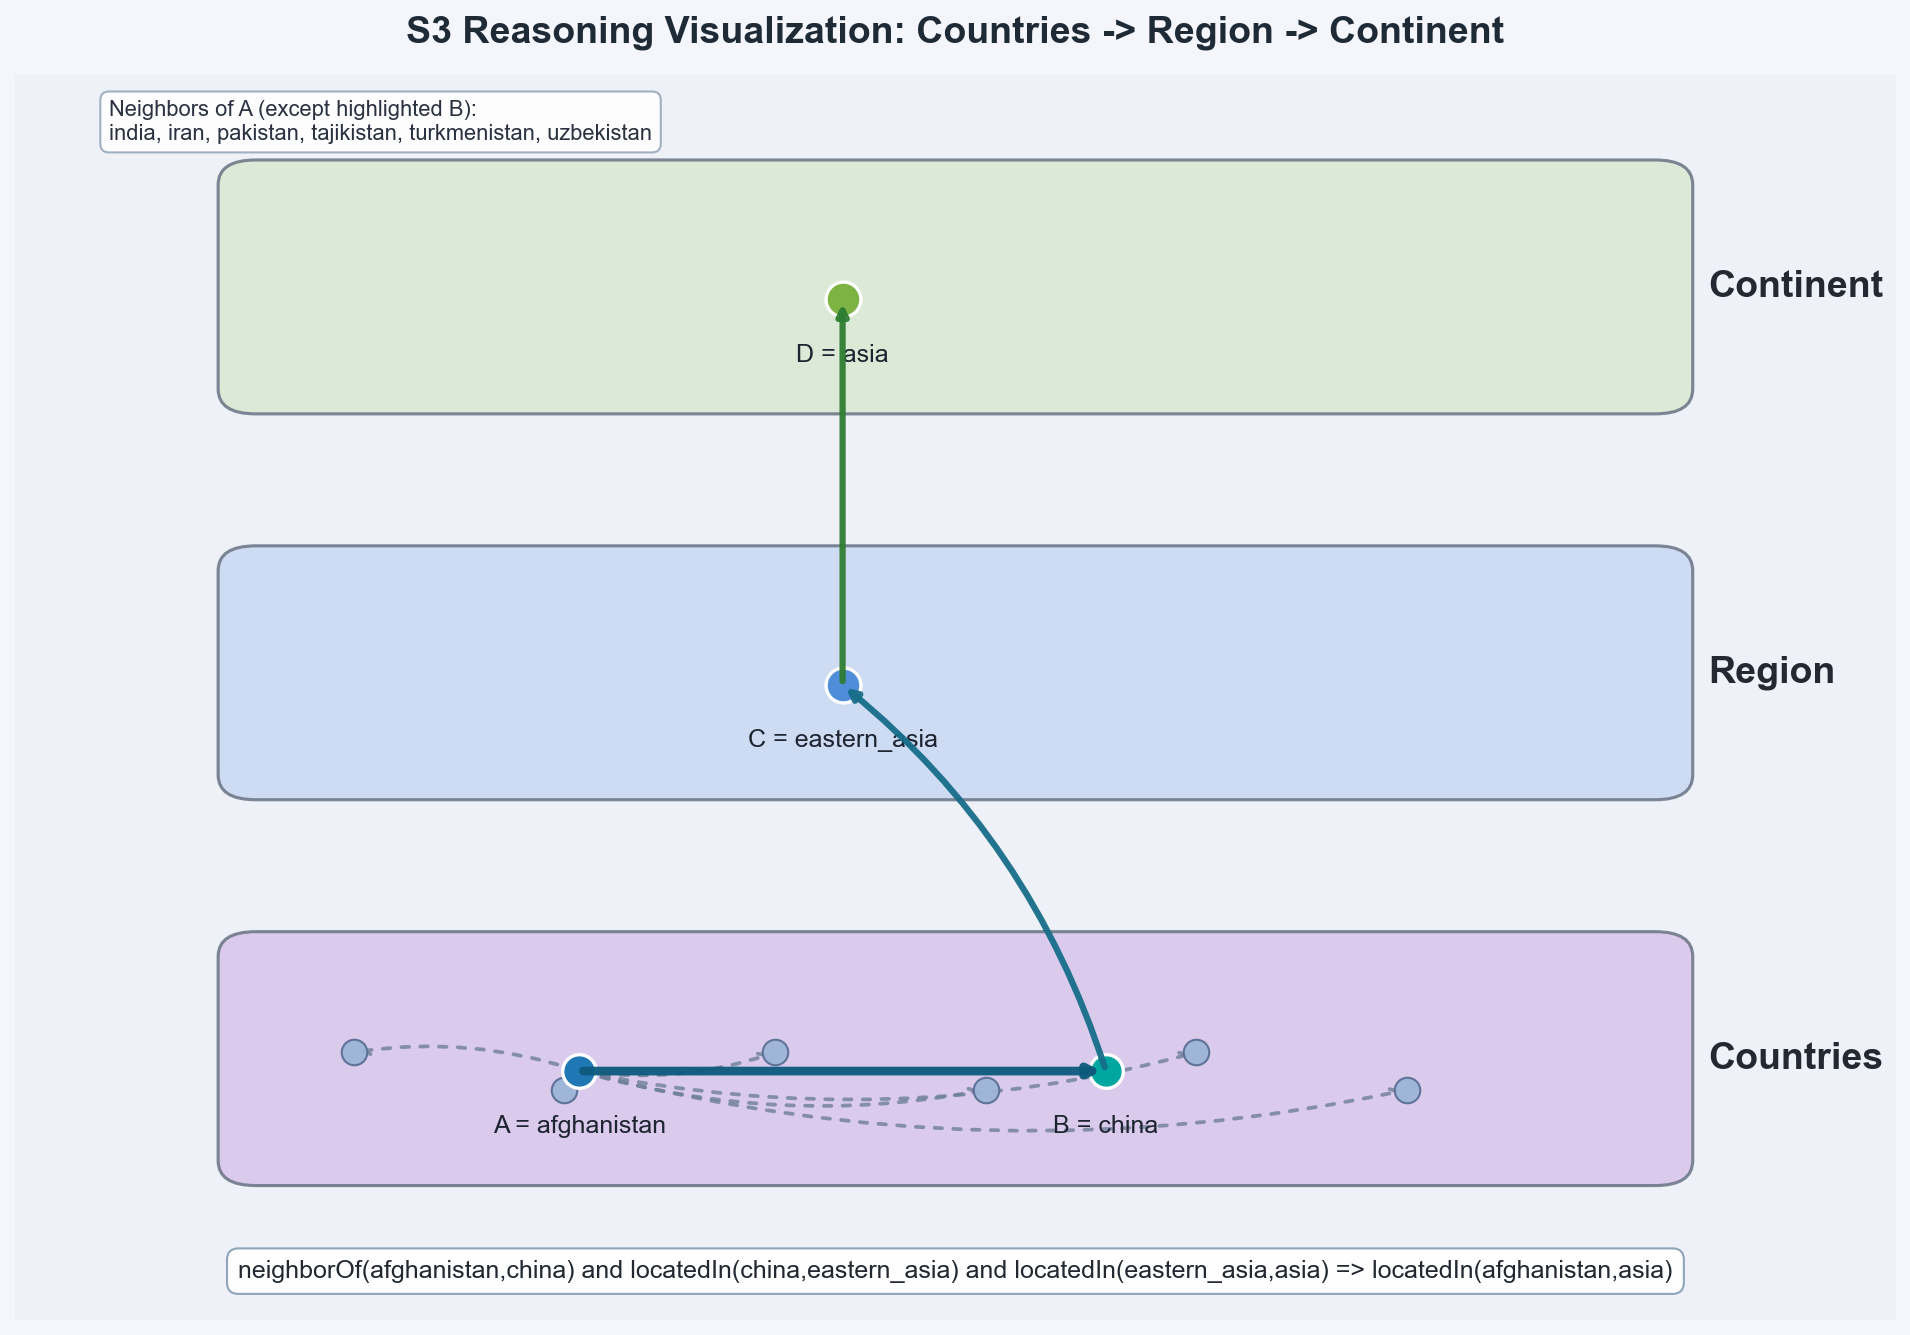

In [10]:
# =============================
# 6) S3 三层结构可视化（高级配色与样式）
# =============================
import random
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# 如果上一个单元没有生成可视化样本，这里兜底生成
if "viz_country" not in globals() or viz_country is None:
    for c in countries:
        p = find_s3_path(c)
        if p is not None:
            viz_country, viz_focus_neighbor, viz_region, viz_continent = p
            viz_neighbors = get_neighbors(viz_country)
            break

# 随机挑一个邻居作为强调路径（若前面没有）
if viz_focus_neighbor is None and viz_neighbors:
    viz_focus_neighbor = random.choice(viz_neighbors)

plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(13, 9), dpi=150)
fig.patch.set_facecolor("#f4f6fb")
ax.set_facecolor("#eef2f8")

# 层级背景面板
layer_specs = [
    (0.12, 0.12, 0.76, 0.18, "Countries", "#d7c5ea"),
    (0.12, 0.43, 0.76, 0.18, "Region", "#c9d9f3"),
    (0.12, 0.74, 0.76, 0.18, "Continent", "#d8e8d1"),
]
for x, y, w, h, label, color in layer_specs:
    panel = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.012,rounding_size=0.02",
        linewidth=1.5,
        edgecolor="#6a7485",
        facecolor=color,
        alpha=0.86,
        transform=ax.transAxes,
    )
    ax.add_patch(panel)
    ax.text(
        x + w + 0.02, y + h / 2, label,
        transform=ax.transAxes,
        va="center", ha="left",
        fontsize=18, fontweight="bold", color="#232833"
    )

# 关键节点坐标（Axes 坐标系）
pos_A = (0.30, 0.20)   # A国
pos_B = (0.58, 0.20)   # 被强调邻居B国
pos_C = (0.44, 0.51)   # 地区C
pos_D = (0.44, 0.82)   # 大区D

# 其它邻居点（虚线路径）
other_neighbors = [n for n in viz_neighbors if n != viz_focus_neighbor]
slots = min(6, len(other_neighbors))
other_xy = []
if slots > 0:
    xs = np.linspace(0.18, 0.74, slots)
    for i in range(slots):
        jitter = 0.015 if i % 2 == 0 else -0.015
        other_xy.append((float(xs[i]), 0.20 + jitter))

# 先画其它邻居和虚线箭头
for i, (x, y) in enumerate(other_xy):
    ax.scatter(
        x, y,
        s=150,
        color="#9db5d8",
        edgecolors="#5a6f94",
        linewidths=1.0,
        alpha=0.95,
        transform=ax.transAxes,
        zorder=3,
    )
    ax.annotate(
        "",
        xy=(x, y), xytext=pos_A,
        xycoords=ax.transAxes, textcoords=ax.transAxes,
        arrowprops=dict(
            arrowstyle="->",
            lw=1.8,
            color="#6f7f99",
            linestyle=(0, (2, 3)),
            alpha=0.8,
            connectionstyle="arc3,rad=0.12",
        ),
        zorder=2,
    )

# 主路径节点（A, B, C, D）
ax.scatter(*pos_A, s=260, color="#1f77b4", edgecolors="white", linewidths=1.6, transform=ax.transAxes, zorder=6)
ax.scatter(*pos_B, s=260, color="#00a7a0", edgecolors="white", linewidths=1.6, transform=ax.transAxes, zorder=6)
ax.scatter(*pos_C, s=280, color="#4f8dd8", edgecolors="white", linewidths=1.6, transform=ax.transAxes, zorder=6)
ax.scatter(*pos_D, s=280, color="#7cb342", edgecolors="white", linewidths=1.6, transform=ax.transAxes, zorder=6)

# 强调箭头: A -> B（加粗）
ax.annotate(
    "",
    xy=pos_B, xytext=pos_A,
    xycoords=ax.transAxes, textcoords=ax.transAxes,
    arrowprops=dict(
        arrowstyle="-|>",
        lw=4.2,
        color="#0d5a7c",
        alpha=0.95,
        connectionstyle="arc3,rad=0.0",
    ),
    zorder=7,
)

# B -> C -> D（S3 主推理链）
ax.annotate(
    "",
    xy=pos_C, xytext=pos_B,
    xycoords=ax.transAxes, textcoords=ax.transAxes,
    arrowprops=dict(
        arrowstyle="-|>",
        lw=3.0,
        color="#176d8a",
        alpha=0.95,
        connectionstyle="arc3,rad=0.15",
    ),
    zorder=7,
)
ax.annotate(
    "",
    xy=pos_D, xytext=pos_C,
    xycoords=ax.transAxes, textcoords=ax.transAxes,
    arrowprops=dict(
        arrowstyle="-|>",
        lw=3.0,
        color="#2f7d32",
        alpha=0.95,
        connectionstyle="arc3,rad=0.0",
    ),
    zorder=7,
)

# 标签与公式
ax.text(pos_A[0], pos_A[1] - 0.05, f"A = {viz_country}", transform=ax.transAxes, ha="center", fontsize=12, color="#1e2430")
ax.text(pos_B[0], pos_B[1] - 0.05, f"B = {viz_focus_neighbor}", transform=ax.transAxes, ha="center", fontsize=12, color="#1e2430")
ax.text(pos_C[0], pos_C[1] - 0.05, f"C = {viz_region}", transform=ax.transAxes, ha="center", fontsize=12, color="#1e2430")
ax.text(pos_D[0], pos_D[1] - 0.05, f"D = {viz_continent}", transform=ax.transAxes, ha="center", fontsize=12, color="#1e2430")

formula = f"neighborOf({viz_country},{viz_focus_neighbor}) and locatedIn({viz_focus_neighbor},{viz_region}) and locatedIn({viz_region},{viz_continent}) => locatedIn({viz_country},{viz_continent})"
ax.text(
    0.5, 0.03, formula,
    transform=ax.transAxes,
    ha="center", va="bottom",
    fontsize=12, color="#222831",
    bbox=dict(boxstyle="round,pad=0.45", facecolor="#ffffff", edgecolor="#8aa0b6", alpha=0.95),
)

# Legend: 其它邻居名单
legend_neighbors = other_neighbors[:12]
legend_text = ", ".join(legend_neighbors) if legend_neighbors else "(none)"
ax.text(
    0.05, 0.98,
    "Neighbors of A (except highlighted B):\n" + legend_text,
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=10.5, color="#2a3140",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="#ffffff", edgecolor="#98a8bc", alpha=0.9),
)

ax.set_title("S3 Reasoning Visualization: Countries -> Region -> Continent", fontsize=18, weight="bold", color="#1f2a37", pad=16)
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()